Korzystanie z narzędzi generatywnej AI w rozwiązywaniu zadań nie jest dozwolone

<img src="no_AI.png" alt="Use of AI allowed only when properly documented " width="100" height="100">

# Zadanie obowiązkowe [0-10] pkt

Użyj zbioru danych [Yeast](https://archive.ics.uci.edu/dataset/110/yeast) i powtórz kroki z ćwiczeń.


1. [0-2 pkt] Używając [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), dokonaj przeszukania przestrzeni hiperparametrów kNN, zmieniając (uargumentuj wybór zakresów):
   1. liczbę sąsiadów
   1. wagę dla sąsiadów
   1. metrykę
1. [0-1.5 pkt] Do wyszukiwania dodaj miary skuteczności m.in. dokładność (*accuracy*) precyzję (*precision*), czułość (*recall*, *sensitivity*), czy też współczynnik korelacji Matthewsa (MCC). Gdzie to możliwe, dostosuj opcje miar, żeby uwzględniały niezbalansowanie zbioru
1. [0-0.5 pkt] Skomentuj wyniki uzyskane w punktach 1 i 2. Spróbuj zinterpretować wyniki
1. [0-2 pkt] Dokonaj selekcji cech, używając [SequentialFeatureSelector](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html). Zmieniaj parametr `n_features_to_select` od dwóch do pięciu. Ile cech uzyskujemy przy opcji `auto`?
1. [0-0.5 pkt] Używając [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), sprawdź wpływ skalowania / normalizacji na wyniki (użyj m.in. `MinMaxScaler` oraz `RobustScaler`)
1. [0-1 pkt] Skomentuj wyniki uzyskane w punktach 4 i 5
1. [0-1.5 pkt] Dla najlepszej pary `n_features_to_select=2` wyryuj obszary decyzyjne. Skomentuj wyniki
1. [0-1 pkt] Czy w świetle uzyskanych wyników, kNN jest odpowiednim klasyfikatorem do tego problemu? Uzasadnij odpowiedź
  
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, matthews_corrcoef, f1_score, ConfusionMatrixDisplay
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, MinMaxScaler
from sklearn.inspection import DecisionBoundaryDisplay
from ucimlrepo import fetch_ucirepo

# Krok 1. Ładowanie danych

In [42]:
yeast = fetch_ucirepo(id=110) 
X = yeast.data.features 
y = yeast.data.targets 

In [43]:
X.shape, len(y)

((1484, 8), 1484)

# Krok 2. Preprocessing

Sprawdzenie ile danych brakuje w zbiorze danych

In [44]:
X[pd.isna(X).any(axis=1)]

,mcg,gvh,alm,mit,erl,pox,vac,nuc


Sprawdzimy, ile jest obiektów danej klasy

In [45]:
y.value_counts()

localization_site
CYT                  463
NUC                  429
MIT                  244
ME3                  163
ME2                   51
ME1                   44
EXC                   35
VAC                   30
POX                   20
ERL                    5
Name: count, dtype: int64

In [46]:
idx_to_drop = y[y['localization_site'] == 'ERL'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)
X, y

(       mcg   gvh   alm   mit  erl  pox   vac   nuc
 0     0.58  0.61  0.47  0.13  0.5  0.0  0.48  0.22
 1     0.43  0.67  0.48  0.27  0.5  0.0  0.53  0.22
 2     0.64  0.62  0.49  0.15  0.5  0.0  0.53  0.22
 3     0.58  0.44  0.57  0.13  0.5  0.0  0.54  0.22
 4     0.42  0.44  0.48  0.54  0.5  0.0  0.48  0.22
 ...    ...   ...   ...   ...  ...  ...   ...   ...
 1479  0.81  0.62  0.43  0.17  0.5  0.0  0.53  0.22
 1480  0.47  0.43  0.61  0.40  0.5  0.0  0.48  0.47
 1481  0.67  0.57  0.36  0.19  0.5  0.0  0.56  0.22
 1482  0.43  0.40  0.60  0.16  0.5  0.0  0.53  0.39
 1483  0.65  0.54  0.54  0.13  0.5  0.0  0.53  0.22
 
 [1479 rows x 8 columns],
      localization_site
 0                  MIT
 1                  MIT
 2                  MIT
 3                  NUC
 4                  MIT
 ...                ...
 1479               ME2
 1480               NUC
 1481               ME2
 1482               NUC
 1483               CYT
 
 [1479 rows x 1 columns])

### Kodowanie kategorii

In [47]:
label_encoder = LabelEncoder()

In [48]:
y_trans = label_encoder.fit_transform(y['localization_site'].values)

### Standaryzacja

In [49]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Krok 3. Klasyfikator kNN

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_trans, stratify=y_trans,
                                                    test_size=0.3, random_state=0)

Nauka modelu

In [51]:
knn = KNeighborsClassifier(n_jobs=-1)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",-1


## Walidacja

In [52]:
y_pred_train = knn.predict(X_train)
y_pred_test  = knn.predict(X_test)

### f1-score

In [53]:
f1_score(y_train, y_pred_train, average='weighted'), \
f1_score(y_test, y_pred_test, average='weighted')

(0.6828753222996756, 0.5581058228196242)

In [54]:
f1_score(y_train, y_pred_train, average='micro'), \
f1_score(y_test, y_pred_test, average='micro')

(0.6927536231884058, 0.5675675675675675)

In [55]:
f1_score(y_train, y_pred_train, average='macro'), \
f1_score(y_test, y_pred_test, average='macro')

(0.610155454847366, 0.5148432334112429)

## Macierz pomyłek

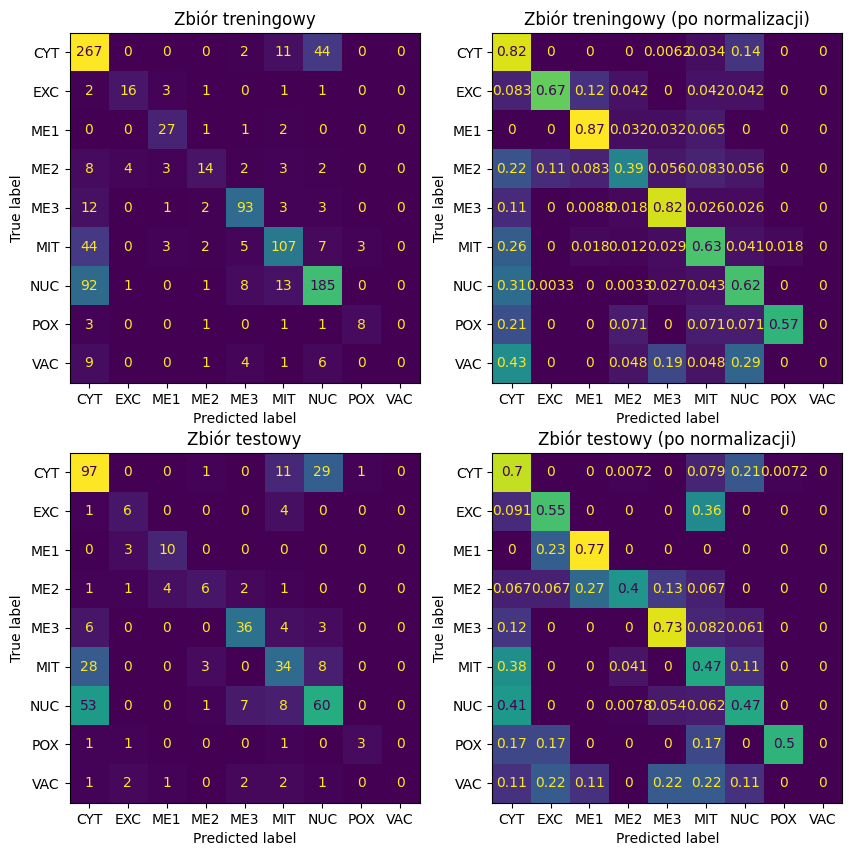

In [56]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
kwargs = {'colorbar': None, 'display_labels': label_encoder.classes_}
labels = ['Zbiór treningowy', 'Zbiór testowy']
for i, (y1, y2) in enumerate(zip([y_train, y_test], [y_pred_train, y_pred_test])):
    ConfusionMatrixDisplay.from_predictions(y1, y2, ax=ax[i, 0], **kwargs)
    ConfusionMatrixDisplay.from_predictions(y1, y2, ax=ax[i, 1], normalize="true", **kwargs)
    ax[i, 0].set_title(f"{labels[i]}")
    ax[i, 1].set_title(f"{labels[i]} (po normalizacji)")
plt.show()

# Krok 4. GridSeachCV

In [57]:
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro', zero_division=0),
    'recall': make_scorer(recall_score, average='macro'),
    'mcc': make_scorer(matthews_corrcoef)
}

param_grid = {
    'n_neighbors': range(1, 31),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, scoring=scoring, refit='mcc', cv=5)
grid_search.fit(X_train, y_train)

print(f"\nNajlepsze parametry: {grid_search.best_params_}")
best_index = grid_search.best_index_
print(f"Accuracy:  {grid_search.cv_results_['mean_test_accuracy'][best_index]:.3f}")
print(f"Precision: {grid_search.cv_results_['mean_test_precision'][best_index]:.3f}")
print(f"Recall:    {grid_search.cv_results_['mean_test_recall'][best_index]:.3f}")
print(f"MCC:       {grid_search.cv_results_['mean_test_mcc'][best_index]:.3f}")


Najlepsze parametry: {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'distance'}
Accuracy:  0.611
Precision: 0.582
Recall:    0.535
MCC:       0.496


Wynik metryki `MCC` na poziomie `0.496` świadczy o tym, że nasz modl jest dość średni. Dość niespodziewanym jest wynik `k=20`, gdyż spodziewałem się osobiście niższego wyniku rzędu maksymalnie 10 sąsiadów. Najbardziej zadziwia mnie `accuracy` na poziomie `61%`. Pokazuje to, że przy tak niezbalnsowanych klasach model osiąga w mojej ocenie dość średnie wyniki i nie jestem zbytnio zadowolony z uzyskanych rezultatów.

In [58]:
results_sfs = []
for n in range(2, 6):
    sfs = SequentialFeatureSelector(
        KNeighborsClassifier(n_neighbors=grid_search.best_params_['n_neighbors']),
        n_features_to_select=n,
        direction='forward',
        scoring='accuracy',
        cv=5
    )
    sfs.fit(X_train, y_train)
    results_sfs.append((n, X.columns[sfs.get_support()].tolist()))

sfs_auto = SequentialFeatureSelector(
    KNeighborsClassifier(n_neighbors=grid_search.best_params_['n_neighbors']),
    n_features_to_select='auto',
    direction='forward',
    cv=5
)
sfs_auto.fit(X_train, y_train)
features_auto = X.columns[sfs_auto.get_support()].tolist()

print("\nWyniki selekcji cech:")
for n, f in results_sfs:
    print(f"n={n}: {f}")
print(f"Opcja 'auto': {len(features_auto)} cechy: {features_auto}")


Wyniki selekcji cech:
n=2: ['alm', 'nuc']
n=3: ['alm', 'mit', 'nuc']
n=4: ['gvh', 'alm', 'mit', 'nuc']
n=5: ['mcg', 'gvh', 'alm', 'mit', 'nuc']
Opcja 'auto': 4 cechy: ['gvh', 'alm', 'mit', 'nuc']


In [59]:
X_train, X_test, y_train, y_test = train_test_split(X, y_trans, stratify=y_trans,
                                                    test_size=0.3, random_state=0)

scalers = {
    'Brak': None,
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

print("\nWpływ skalowania na wyniki (Accuracy):")
for name, scaler in scalers.items():
    steps = []
    if scaler: steps.append(('scaler', scaler))
    steps.append(('knn', KNeighborsClassifier(**grid_search.best_params_)))
    
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)
    score = pipeline.score(X_test, y_test)
    print(f"{name}: {score:.4f}")


Wpływ skalowania na wyniki (Accuracy):
Brak: 0.6171
MinMaxScaler: 0.6104
RobustScaler: 0.5968


Opcja `auto` zwróciła, że najlepszym wyjściem byłoby stworzenei tego modelu wykorzystując 4 cechy. Patrząc na to, że domyślnie mamy 8 cech, wykluczenie połowy to dość sporo i może wskazywać na to, że model cierpi klątwę wymiarowości, gdzie nasze dane próbkowe zanikają w tak wielu wymiarach. Zmniejszenie liczby wymiarów powinno skutkować mniejszym wpływem nieznaczących szumów na finalny wynik nie tracąc rezultatów. Okazało się, że najlepszymi cechami są `alm` oraz `nuc` i za każdym razem, od 2 do 5 cech, zawsze były one wybierane. Skalowanie danych negatywnie wpłynęło na model, ponieważ zarówno dla `MinMaxScaler` jak i dla `RobustScaler` accuracy modelu spadło względem domyślnych. Może to być spowodowane tym, że dane wejściowe są już na samym początku w większości w przedziale `[0, 1]` i ich skalowanie nie ma sensu

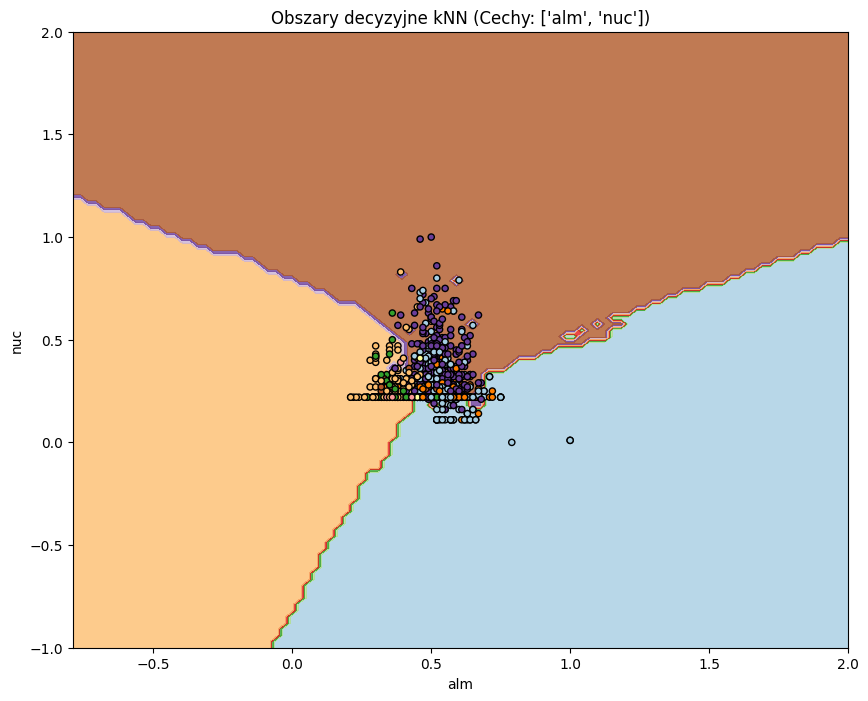

In [60]:
best_2_features = results_sfs[0][1]
X_2d = X[best_2_features].values
y_2d = y_trans

knn_2d = KNeighborsClassifier(**grid_search.best_params_)
knn_2d.fit(X_2d, y_2d)

plt.figure(figsize=(10, 8))
DecisionBoundaryDisplay.from_estimator(
    knn_2d, X_2d, response_method="predict",
    cmap=plt.cm.Paired, alpha=0.8, ax=plt.gca()
)
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, edgecolors='k', cmap=plt.cm.Paired, s=20)
plt.title(f"Obszary decyzyjne kNN (Cechy: {best_2_features})")
plt.xlabel(best_2_features[0])
plt.ylabel(best_2_features[1])
plt.show()

Widać na wykresie, że model podzielił całą przestrzeń na 3 najważniejsze klasy. Nie widać żadnych innych obszarów, niż brązowy, żółty oraz niebieski. Na wykresie można zauważyć dość duże natężenie punktów obok siebie, co również mogło nagatywnie wpłynąć na wynik naszego modelu. Dobór tylko 2 cech pokazuje, że ten model badzo spłaszczyłby możliwe wyniki ograniczając je tak naprawdę do 3 klas o reszcie prawie że całkowicie zapominając

# Podsumowanie

Podsumowując, model ten nie za bardzo nadawał się do `kNN`. Otrzymane wyniki są mocno niesatysfakconujące i będąc szczerym, nie chciałbym oddawać takiego modelu klientowi finalnemu. Jednakże warto zwrócić uwagę na przewidywane wyniki modelu przedstawione na stronie, skąd wzięty został dataset. Średnie accuracy wynosi okło właśnie `60-70%` używając lasów losowych czy XGBoost. Porównując z naszymi `61%` maksymalnego accuracy pokazuje to, że nie dość iż rozwiązanie niezbyt nadaje się do tego datasetu, to sam dataset w sobie jest niezbyt dobry. Ale wracając czemu `kNN` nie jest zbyt opytmalnym rozwiązaniem. Problemem jest tutaj bardzo gęsta sieć leżących obok siebie przeróznych klas. Wykres z zadania 7 pokazuje, jak gęsto różne klasy leżą obok siebie. Wiadomo - jest to tylko uproszcenie do 2 cech, jednakże poza nielicznymi wyjątkami wszystkie obiekty/klasy znajdują się w tuż przy sobie. Dodatkowo negatywnie wpływa to, że model cierpiał na klątwę wymiarowości. To, że przy 8 cechach najlepsze wyniki model miał osiągać przy 4 cechach jest jasnym sygnałem na występowanie tego problemu. Bardzo możliwe, że zakres wartości dla każdej z cech z zakres `[0.1, 1.0]` mógł negatywnie wpłynąć na model, co pokazało skalowanie/normalizacja tym, że model pogoszyła zamiast poprawić. Moim zdaniem, `kNN` nie nadawał się do tego datasetu, choć i tak po stronie UCI widać, że każde rozwiązanie niezbyt się do niego nadaje